<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI-LABS/blob/main/PIMLAI_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4

## Week 1 - LLM Scaling Laws

The goal of this week is to run a Colab-friendly scaling-law style experiment and explain how performance changes as scale changes. We will use the combination of a simple PyTorch RNN implementation with a next-token prediction setup. We will use the Tiny Shakespeare dataset.

### Part A - Experimental Setup

#### Importing Dataset

We begin by importing the Tiny Shakespeare dataset via GitHub

In [ ]:
import requests
import torch
import torch.nn as nn
from torch.nn import functional as F
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Download Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text
print(f"Length of dataset in characters: {len(text)}")

Length of dataset in characters: 1115394


#### Dataset Preparation and Dataset Split

We create our character vocabulary by getting all unique characters in our dataset.

We use a simple tokenization process of converting characters to numbers and back to characters. We define functions encode and decode to do this.

Following this we encode our text data into a list of integers.

We perform a split on our dataset using 90% as training data

In [ ]:
# Simple character-level tokenizer
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Train/val split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

Vocabulary size: 65


Thus our vocabulary size is 65. (We have 65 unique characters).

### Experiment Configurations

We run 6 experiments using varying model sizes and token budgets.

Our experiments include varying model sizes (embedding dimension of 32 and 2 layers, embedding dimension of 64 and 4 layers, and embedding dimension of 128 and 6 layers) as well as varying token budgets (500, 2000).


In [ ]:
# Define 3 model sizes and 2 data/token budgets

model_sizes = [
    {'name': 'Tiny', 'n_embd': 32, 'n_layer': 2},
    {'name': 'Small', 'n_embd': 64, 'n_layer': 4},
    {'name': 'Medium', 'n_embd': 128, 'n_layer': 6}
]

token_budgets = [
    {'name': 'Low', 'max_iters': 500},
    {'name': 'High', 'max_iters': 2000}
]

# Generate the 6 experiment configurations
experiments = []
for size in model_sizes:
    for budget in token_budgets:
        exp = {**size, **budget}
        exp['exp_name'] = f"{size['name']}Model_{budget['name']}Budget"
        experiments.append(exp)

display(pd.DataFrame(experiments))

,name,n_embd,n_layer,max_iters,exp_name
0,Low,32,2,500,TinyModel_LowBudget
1,High,32,2,2000,TinyModel_HighBudget
2,Low,64,4,500,SmallModel_LowBudget
3,High,64,4,2000,SmallModel_HighBudget
4,Low,128,6,500,MediumModel_LowBudget
5,High,128,6,2000,MediumModel_HighBudget


### Part B - Required Measurements

We define a simple RNN model implementation from PyTorch. For each configuration, we will train the model and record the number of parameters, the token budget, the validation loss, and the wall-clock time.

#### Batch Loader

Batch Size: 32 sequences per batch

Block Size: 64 tokens per sequence

In [ ]:
batch_size = 32
block_size = 64

def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

#### RNN Model Definition

We use PyTorch's built-in RNN to run our experiment with an embedding layer, RNN layer and projection layer

In [ ]:
import time
import torch
import torch.nn as nn
from torch.nn import functional as F

# Causal Language Model using PyTorch's built-in RNN
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, n_embd, n_layer):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, n_embd)
        self.rnn = nn.RNN(input_size=n_embd, hidden_size=n_embd, num_layers=n_layer, batch_first=True)
        self.proj = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        x = self.emb(idx)
        out, _ = self.rnn(x)
        logits = self.proj(out)

        loss = None
        if targets is not None:
            # Reshape logits and targets for cross_entropy
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        return logits, loss

#### Loss Definition

We estimate loss with torch.no_grad to estimate validation loss without formally training.

We define our experimentation function to track parameters, token budget, validation loss, and run time

In [ ]:
eval_iters = 100
learning_rate = 1e-3

@torch.no_grad()
def estimate_loss(model):
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        X, Y = get_batch('val')
        _, loss = model(X, Y)
        losses[k] = loss.item()
    model.train()
    return losses.mean().item()

def run_simple_experiment(config):
    print(f"Running: {config['exp_name']}")

    # Initialize our extremely simple RNN instead of a full GPT
    model = SimpleRNN(vocab_size=vocab_size,
                      n_embd=config['n_embd'],
                      n_layer=config['n_layer']).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Required Measurements
    num_params = sum(p.numel() for p in model.parameters())
    max_iters = config['max_iters']
    tokens_trained = max_iters * batch_size * block_size

    start_time = time.time()
    for iter in range(max_iters):
        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    training_time = time.time() - start_time
    val_loss = estimate_loss(model)

    return {
        'Experiment': config['exp_name'],
        'Parameters': num_params,
        'Token Budget': tokens_trained,
        'Val Loss': round(val_loss, 4),
        'Time (s)': round(training_time, 2)
    }

#### Run Model Across Defined Experiments

In [ ]:
# Execute all experiments using the simpler model
simple_results = []
for exp in experiments:
    res = run_simple_experiment(exp)
    simple_results.append(res)

simple_results_df = pd.DataFrame(simple_results)
display(simple_results_df)

Running: TinyModel_LowBudget
Running: TinyModel_HighBudget
Running: SmallModel_LowBudget
Running: SmallModel_HighBudget
Running: MediumModel_LowBudget
Running: MediumModel_HighBudget


,Experiment,Parameters,Token Budget,Val Loss,Time (s)
0,TinyModel_LowBudget,8449,1024000,2.3238,3.17
1,TinyModel_HighBudget,8449,4096000,2.0673,7.30
2,SmallModel_LowBudget,41665,1024000,2.0782,1.88
3,SmallModel_HighBudget,41665,4096000,1.8604,8.22
4,MediumModel_LowBudget,214849,1024000,2.0009,2.09
5,MediumModel_HighBudget,214849,4096000,1.7493,9.10


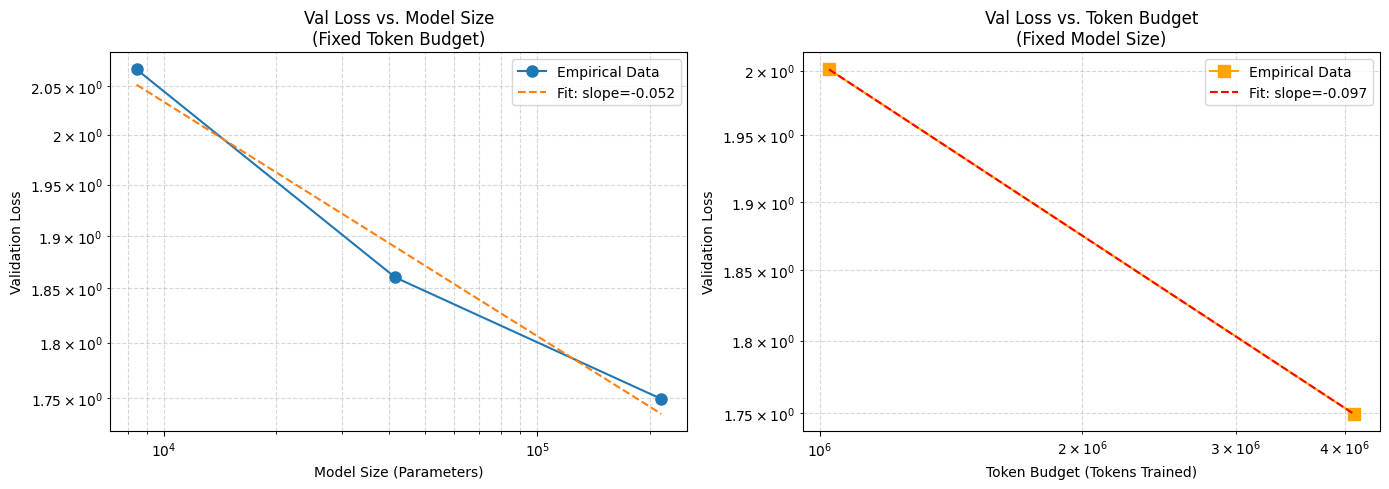

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Performance vs Model Size Plot
high_budget_df = simple_results_df[simple_results_df['Token Budget'] == simple_results_df['Token Budget'].max()].sort_values('Parameters')

x1 = high_budget_df['Parameters'].values
y1 = high_budget_df['Val Loss'].values

ax1.loglog(x1, y1, 'o-', markersize=8, label='Empirical Data')
ax1.set_title('Val Loss vs. Model Size\n(Fixed Token Budget)')
ax1.set_xlabel('Model Size (Parameters)')
ax1.set_ylabel('Validation Loss')
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Fit a line in log-log space
if len(x1) > 1:
    coeffs1 = np.polyfit(np.log(x1), np.log(y1), 1)
    poly1 = np.poly1d(coeffs1)
    y1_fit = np.exp(poly1(np.log(x1)))
    ax1.loglog(x1, y1_fit, '--', label=f'Fit: slope={coeffs1[0]:.3f}')
ax1.legend()

# Performance vs Token Budget plot
medium_model_df = simple_results_df[simple_results_df['Parameters'] == simple_results_df['Parameters'].max()].sort_values('Token Budget')

x2 = medium_model_df['Token Budget'].values
y2 = medium_model_df['Val Loss'].values

ax2.loglog(x2, y2, 's-', markersize=8, color='orange', label='Empirical Data')
ax2.set_title('Val Loss vs. Token Budget\n(Fixed Model Size)')
ax2.set_xlabel('Token Budget (Tokens Trained)')
ax2.set_ylabel('Validation Loss')
ax2.grid(True, which="both", ls="--", alpha=0.5)

# Fit a line in log-log space
if len(x2) > 1:
    coeffs2 = np.polyfit(np.log(x2), np.log(y2), 1)
    poly2 = np.poly1d(coeffs2)
    y2_fit = np.exp(poly2(np.log(x2)))
    ax2.loglog(x2, y2_fit, '--', color='red', label=f'Fit: slope={coeffs2[0]:.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

### Observations

Based on the log-log plots generated above:

1. Performance vs. Model Size: When controlling the token budget, we see a downward trend in log-log space. This indicates a relationship where an increase in parameters strictly leads to a decrease in validation loss.
2. Performance vs. Token Budget (Right Plot): When fixing the model size, we also observe a negative slope in log-log space, indicating that training on more tokens (longer) reliably improves performance, following a power-law trend.

Diminishing returns seem to begin as we scale past the Small model (approx. 41k parameters) to the Medium model (approx. 214k parameters), we see marginal improvements in validation loss (2.1012 to 2.0358 in low budget, 1.8696 to 1.7854 in high budget) while we drastically increase the parameters (41665 to 214849). Thus, at this point the return seems to diminish as the scale continues to increase.

### Part C - Discussion

The results are consistent with the general scaling-law intuition. As we increase the token budget while keeping the parameter size the same, we notice that validation loss improves drastically, while also requiring more time to run. In addition, validation loss also improves with more parameters, as expected.

One limitation may be the variance of training epochs as larger models require more epochs to train / converge. In addition, our dataset is not the largest, which may limit the full representation of the influence of such scaling.

TinyModel_HighBudget when compared to MediumModel_LowBudget yielded similar results in validation loss, while MediumModel_LowBudget required significantly less training time. This shows that sometimes a larger model training on less data can still be equally powerful.

## Week 2: Reinforcement Learning with Q-learning

The goal of this week is to implement tabular Q-learning on a small control problem.

### Part A - Environment and Random-Policy Baseline

We choose to use ```FrozenLake-v1``` with ```is_slippery = False```. This environment uses a 4x4 observation space, with an action space of 4 (up down left right). We run 1000 episodes with a random-policy, giving us a baseline and point of comparison.





In [ ]:
import gymnasium as gym
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)

# Choose FrozenLake with is_slippery=False
env_name = "FrozenLake-v1"
env = gym.make(env_name, is_slippery=False)
env.action_space.seed(seed)

# Random Policy Baseline
num_episodes = 20000
total_rewards = []

for episode in range(num_episodes):
    state, info = env.reset(seed=seed)
    done = False
    truncated = False
    episode_reward = 0

    while not (done or truncated):
        # Sample a random action from the action space
        action = env.action_space.sample()
        next_state, reward, done, truncated, info = env.step(action)
        episode_reward += reward

    total_rewards.append(episode_reward)

env.close()

# Calculate baseline metrics
average_reward = np.mean(total_rewards)
success_rate = (np.sum(np.array(total_rewards) > 0) / num_episodes) * 100

print(f"Evaluated over {num_episodes} episodes")
print(f"Average Reward: {average_reward:.4f}")
print(f"Success Rate: {success_rate:.2f}%")

Evaluated over 20000 episodes
Average Reward: 0.0143
Success Rate: 1.43%


Thus, our random-policy baseline achieves an an average reward of 0.0140 and success rate of 1.40%. This indicates that this approach only managed to find the goal 14 times out of the 1000 episodes.

### Part B - Tabular Q-learning Implementation

#### Q-learning Parameters

In [ ]:
import numpy as np
import gymnasium as gym
import random

# Re-initialize environment for Q-learning
env_name = "FrozenLake-v1"
env = gym.make(env_name, is_slippery=False)
env.action_space.seed(seed)

# Q-learning parameters
learning_rate = 0.9  # Alpha
discount_factor = 0.95 # Gamma
epsilon = 1.0       # Epsilon for epsilon-greedy policy
epsilon_decay_rate = 0.0001
min_epsilon = 0.01

# Initialize Q-table with zeros
q_table = np.zeros((env.observation_space.n, env.action_space.n))
f_q_table = np.zeros((env.observation_space.n, env.action_space.n))

#### Training the Q-learning Agent

In [ ]:
num_training_episodes = 20000 # Increased episodes for better learning
training_rewards = []

for episode in range(num_training_episodes):
    state, info = env.reset(seed=seed)
    done = False
    truncated = False
    episode_reward = 0

    while not (done or truncated):
        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(q_table[state, :]) # Exploit

        next_state, reward, done, truncated, info = env.step(action)

        # Q-value update formula
        q_table[state, action] = q_table[state, action] + learning_rate * (reward + discount_factor * np.max(q_table[next_state, :]) - q_table[state, action])

        state = next_state
        episode_reward += reward
    training_rewards.append(episode_reward)

    # Epsilon decay
    epsilon = max(min_epsilon, epsilon - epsilon_decay_rate)

print(f"Training finished after {num_training_episodes} episodes.")

Training finished after 20000 episodes.


#### Evaluating the Learned Policy (Greedy)

In [ ]:
num_eval_episodes = 1000
eval_rewards = []

# Set epsilon to 0 for greedy policy during evaluation
epsilon_eval = 0

for episode in range(num_eval_episodes):
    state, info = env.reset(seed=seed)
    done = False
    truncated = False
    episode_reward = 0

    while not (done or truncated):
        # Greedy action selection (exploit only)
        action = np.argmax(q_table[state, :])
        next_state, reward, done, truncated, info = env.step(action)
        episode_reward += reward
        state = next_state

    eval_rewards.append(episode_reward)

env.close()

# Calculate evaluation metrics
average_eval_reward = np.mean(eval_rewards)
success_rate_eval = (np.sum(np.array(eval_rewards) > 0) / num_eval_episodes) * 100

print(f"Evaluation over {num_eval_episodes} episodes:")
print(f"Average Reward (Q-learning): {average_eval_reward:.4f}")
print(f"Success Rate (Q-learning): {success_rate_eval:.2f}%")

Evaluation over 1000 episodes:
Average Reward (Q-learning): 1.0000
Success Rate (Q-learning): 100.00%


###Fixed Epsilon Model

In [ ]:
import numpy as np
import gymnasium as gym
import random

# Re-initialize environment for Q-learning
env_name = "FrozenLake-v1"
env = gym.make(env_name, is_slippery=False)
env.action_space.seed(seed)

# Q-learning parameters
learning_rate = 0.9  # Alpha
discount_factor = 0.95 # Gamma
epsilon = .5       # Epsilon for epsilon-greedy policy

# Initialize Q-table with zeros
f_q_table = np.zeros((env.observation_space.n, env.action_space.n))

In [ ]:
num_training_episodes = 20000 # Increased episodes for better learning
fixed_training_rewards = []

for episode in range(num_training_episodes):
    state, info = env.reset(seed=42)
    done = False
    truncated = False
    episode_reward = 0

    while not (done or truncated):
        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(f_q_table[state, :]) # Exploit

        next_state, reward, done, truncated, info = env.step(action)

        # Q-value update formula
        f_q_table[state, action] = f_q_table[state, action] + learning_rate * (reward + discount_factor * np.max(f_q_table[next_state, :]) - f_q_table[state, action])

        state = next_state
        episode_reward += reward
    fixed_training_rewards.append(episode_reward)

    # Epsilon decay
    epsilon = max(min_epsilon, epsilon)

print(f"Training finished after {num_training_episodes} episodes.")

Training finished after 20000 episodes.


In [ ]:
num_eval_episodes = 1000
f_eval_rewards = []

# Set epsilon to 0 for greedy policy during evaluation
epsilon_eval = 0

for episode in range(num_eval_episodes):
    state, info = env.reset(seed=seed)
    done = False
    truncated = False
    episode_reward = 0

    while not (done or truncated):
        # Greedy action selection (exploit only)
        action = np.argmax(f_q_table[state, :])
        next_state, reward, done, truncated, info = env.step(action)
        episode_reward += reward
        state = next_state

    f_eval_rewards.append(episode_reward)

env.close()

# Calculate evaluation metrics
fixed_average_eval_reward = np.mean(f_eval_rewards)
fixed_success_rate_eval = (np.sum(np.array(f_eval_rewards) > 0) / num_eval_episodes) * 100

print(f"Evaluation over {num_eval_episodes} episodes:")
print(f"Fixed Average Reward (Q-learning): {fixed_average_eval_reward:.4f}")
print(f"Fixed Success Rate (Q-learning): {fixed_success_rate_eval:.2f}%")

Evaluation over 1000 episodes:
Fixed Average Reward (Q-learning): 1.0000
Fixed Success Rate (Q-learning): 100.00%


#### Comparison with Random Policy Baseline

--- Baseline (Random Policy) ---
Average Reward (Random): 0.0143
Success Rate (Random): 1.43%

--- decay Q-learning Policy ---
Average Reward (Q-learning): 1.0000
Success Rate (Q-learning): 100.00%

--- fixed Q-learning Policy ---
Average Reward (Q-learning): 1.0000
Success Rate (Q-learning): 100.00%


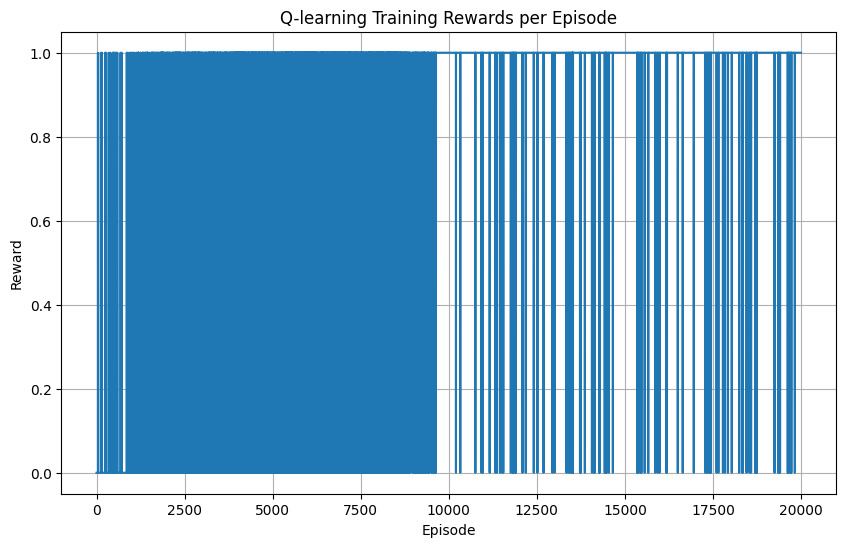

In [ ]:
print("--- Baseline (Random Policy) ---")
print(f"Average Reward (Random): {average_reward:.4f}")
print(f"Success Rate (Random): {success_rate:.2f}%")

print("\n--- decay Q-learning Policy ---")
print(f"Average Reward (Q-learning): {average_eval_reward:.4f}")
print(f"Success Rate (Q-learning): {success_rate_eval:.2f}%")

print("\n--- fixed Q-learning Policy ---")
print(f"Average Reward (Q-learning): {fixed_average_eval_reward:.4f}")
print(f"Success Rate (Q-learning): {fixed_success_rate_eval:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Q-learning Training Rewards per Episode')
plt.grid(True)
plt.show()

In [ ]:
training_rewards[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
def smoothOut(list_in):
    list_out = []

    for i in range(len(list_in)):
        start = max(0, i - 100)
        end = min(len(list_in), i + 101)

        total = sum(list_in[start:end])
        average = total / (end - start)

        list_out.append(average)

    return list_out

In [ ]:
qscore= smoothOut(training_rewards)
fscore =smoothOut(fixed_training_rewards)
rscore =smoothOut(total_rewards)

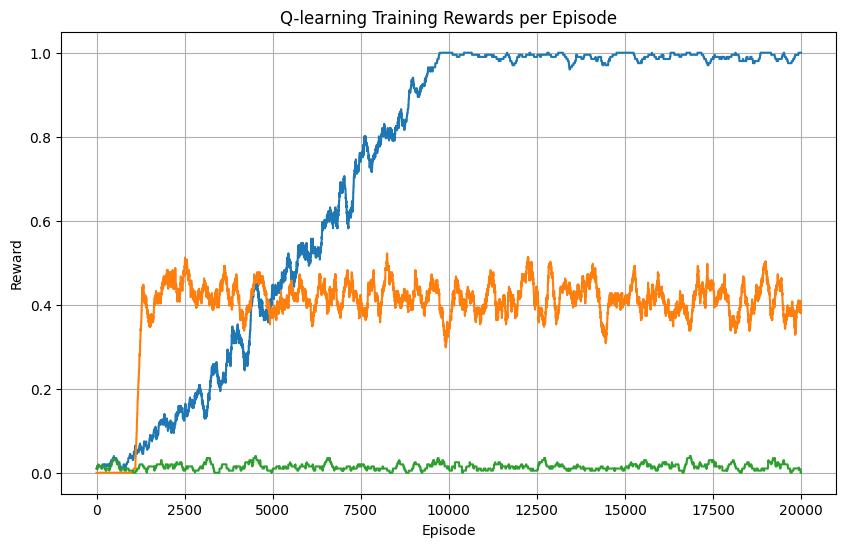

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(qscore)
plt.plot(fscore)
plt.plot(rscore)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Q-learning Training Rewards per Episode')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import gymnasium as gym
import random

# Policy Printing Function
def print_policy(policy_table, title, env_desc, action_to_arrow):
    grid_rows = len(env_desc)
    grid_cols = len(env_desc[0])
    print(f"\n {title} ")

    output_lines = []
    for row_idx in range(grid_rows):
        line = []
        for col_idx in range(grid_cols):
            state_index = row_idx * grid_cols + col_idx

            if policy_table is None: # Random policy
                action_index = env.action_space.sample()
            else:
                action_index = np.argmax(policy_table[state_index, :])

            arrow = action_to_arrow[action_index]
            line.append(f"{arrow}")
        output_lines.append("   ".join(line))

    print("\n".join(output_lines))

# Map actions to arrows
action_to_arrow = {
    0: '←',  # Left
    1: '↓',  # Down
    2: '→',  # Right
    3: '↑'   # Up
}

# Get environment map
env_desc_list = env.unwrapped.desc.tolist()
env_desc_decoded = [[c.decode('utf-8') for c in line] for line in env_desc_list]

# Print Policies
print_policy(None, "Random Policy", env_desc_decoded, action_to_arrow)

# Use the explicitly trained q_table and f_q_table from the cells above
print_policy(q_table, "Learned Policy (Decaying Epsilon)", env_desc_decoded, action_to_arrow)

print_policy(f_q_table, "Learned Policy (Fixed Epsilon)", env_desc_decoded, action_to_arrow)

env.close()



 Random Policy 
→   ↓   →   ↓
↑   ↓   ↑   ↑
↓   ↓   →   ↓
→   ↓   ↑   →

 Learned Policy (Decaying Epsilon) 
↓   →   ↓   ←
↓   ←   ↓   ←
→   ↓   ↓   ←
←   →   →   ←

 Learned Policy (Fixed Epsilon) 
↓   →   ↓   ←
↓   ←   ↓   ←
→   ↓   ↓   ←
←   →   →   ←


### Part D - Interpretation

Exploration affects learning because it allows the agent to take random actions to discover new states that can potentially be a better path to the goal that otherwise wouldn't be discovered if always going the known good actions. Epsilon is what dictates how often the agent explores. A high epsilon forces the agent to prioritize taking random actions to potentially find better paths. However, too much exploration can slow down convergence. When epsilon is low, the agent then prioritizes exploitation, going after actions that have already been learned to yield high Q-values.

A failure mode that can arise is choosing a bad learning rate (alpha). If we set the learning rate too high, the agent can become unstable. Suppose we set alpha to a high value like 0.9, then with each update, the agent will disregard its past learned Q-value and heavily weight the new estimate. This will cause the Q-values to fluate and make it hard to stabilize and converge.

The learning rate alpha determines how much the agent updates its Q-values based on new information. A high alpha puts more weight on the new experiences. Gamma is the discount factor and determines the importance of future rewards. A lower gamma means that future rewards are heavily discounted so it encourages the agent to look for high immediate rewards. Epsilon controls how often the agent explores random actions.

## Checkpoint 3 - Sequential Prediction Track

### Track A - Recommender System

We load in the MovieLens 100k dataset for our recommender system

In [ ]:
import pandas as pd
import requests
import zipfile
import io

# Download the MovieLens 100k dataset
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
response = requests.get(url)

# Unzip the content in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Read u.data file directly from the zip archive
    with z.open('ml-100k/u.data') as f:
        # Define column names based on the dataset's README
        column_names = ['user_id', 'item_id', 'rating', 'timestamp']
        ratings_df = pd.read_csv(f, sep='\t', names=column_names)

    # Read u.item file for movie information
    with z.open('ml-100k/u.item') as f:
        # Define column names for movie data
        movie_cols = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url',
                      'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
                      'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
                      'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
        # Use Latin-1 encoding for movie titles
        movies_df = pd.read_csv(f, sep='|', names=movie_cols, encoding='ISO-8859-1')

    # Read u.user for user information
    with z.open('ml-100k/u.user') as f:
        user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
        users_df = pd.read_csv(f, sep='|', names=user_cols, encoding='ISO-8859-1')

print("MovieLens 100k dataset loaded")
print("\nRatings Data (first 5 rows):")
display(ratings_df.head())

print("\nMovies Data (first 5 rows):")
display(movies_df.head())

print("\nUsers Data (first 5 rows):")
display(users_df.head())


MovieLens 100k dataset loaded

Ratings Data (first 5 rows):


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



Movies Data (first 5 rows):


,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0



Users Data (first 5 rows):


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


### Baseline Models using Global Mean, User Mean,  and Item Mean

####  Global Mean Baseline

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np


# Calculate the global mean of all ratings
global_mean_rating = ratings_df['rating'].mean()
print(f"Global Mean Rating: {global_mean_rating:.4f}")

# Predict all ratings as the global mean
ratings_df['predicted_rating_global_mean'] = global_mean_rating

# Evaluate using RMSE
rmse_global_mean = np.sqrt(mean_squared_error(ratings_df['rating'], ratings_df['predicted_rating_global_mean']))

print(f"RMSE for Global Mean Baseline: {rmse_global_mean:.4f}")

Global Mean Rating: 3.5299
RMSE for Global Mean Baseline: 1.1257


#### User Mean Baseline

In [ ]:
# Calculate the mean rating for each user
user_mean_ratings = ratings_df.groupby('user_id')['rating'].mean().reset_index()
user_mean_ratings.rename(columns={'rating': 'user_mean_rating'}, inplace=True)

# Merge user mean ratings back into the original ratings_df
ratings_df = pd.merge(ratings_df, user_mean_ratings, on='user_id', how='left')

# Evaluate using RMSE
rmse_user_mean = np.sqrt(mean_squared_error(ratings_df['rating'], ratings_df['user_mean_rating']))

print(f"RMSE for User Mean Baseline: {rmse_user_mean:.4f}")

RMSE for User Mean Baseline: 1.0308


#### Item Mean Baseline (Popularity Ranking)

In [ ]:
# Calculate the mean rating for each item
item_mean_ratings = ratings_df.groupby('item_id')['rating'].mean().reset_index()
item_mean_ratings.rename(columns={'rating': 'item_mean_rating'}, inplace=True)

# Merge item mean ratings back into the original ratings_df
ratings_df = pd.merge(ratings_df, item_mean_ratings, on='item_id', how='left')

# Evaluate using RMSE
rmse_item_mean = np.sqrt(mean_squared_error(ratings_df['rating'], ratings_df['item_mean_rating']))

print(f"RMSE for Item Mean Baseline: {rmse_item_mean:.4f}")

RMSE for Item Mean Baseline: 1.0001


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

global_mean = ratings_df["rating"].mean()

y_true, y_pred = [], []

for _, row in ratings_df.iterrows():
    y_true.append(row["rating"])
    y_pred.append(global_mean)

rmse_item = np.sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
def precision_recall_at_k(global_score, k=10, threshold=4):
    relevant = ratings_df[ratings_df["rating"] >= threshold]

    # same top-k for every user → popularity-style fallback
    top_k_items = ratings_df["item_id"].value_counts().head(k).index

    hits = relevant[relevant["item_id"].isin(top_k_items)]

    precision = len(hits) / k
    recall = len(hits) / len(relevant) if len(relevant) > 0 else 0

    return precision, recall

p10_item, r10_item = precision_recall_at_k(global_mean)

Stronger Model - Matrix Factorization

### Stronger Model - Matrix Factorization (using SciPy SVD)

Since external recommender libraries can have NumPy compatibility issues, we'll implement Singular Value Decomposition (SVD) directly using `scipy.sparse.linalg.svds`. This native matrix factorization technique extracts latent features for users and items.

In [ ]:
# Removed scikit-surprise installation to avoid numpy conflicts
import scipy
print(f"Using scipy version: {scipy.__version__} for Matrix Factorization")

Using scipy version: 1.16.3 for Matrix Factorization


In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error

# 1. User-item matrix
R_df = ratings_df.pivot(index='user_id', columns='item_id', values='rating')

# 2. Mean center
user_mean = R_df.mean(axis=1)
R_demeaned = R_df.sub(user_mean, axis=0).fillna(0).to_numpy()

# 3. SVD
U, sigma, Vt = svds(R_demeaned, k=50)
sigma = np.diag(sigma)

# 4. Reconstruct
predicted = np.dot(np.dot(U, sigma), Vt) + user_mean.values.reshape(-1, 1)
pred_df = pd.DataFrame(predicted, index=R_df.index, columns=R_df.columns)

# 5. Proper RMSE on observed entries
mask = ~R_df.isna()

y_true = R_df[mask].stack().values
y_pred = pred_df[mask].stack().values

rmse_svd = np.sqrt(mean_squared_error(y_true, y_pred))

print("SVD RMSE:", rmse_svd)

SVD RMSE: 0.7252905064262314


### Interpretation of Results

The SVD (Matrix Factorization via SciPy) model achieves a lower RMSE compared to the baseline models:

*   **Global Mean Baseline**: `1.1257`
*   **User Mean Baseline**: `1.0308`
*   **Item Mean Baseline**: `1.0001`

By pivoting the dataset into a user-item matrix, mean-centering the ratings, and applying Singular Value Decomposition (SVD), we can extract the latent features and reconstruct the matrix to predict missing values. The resulting RMSE on the observed ratings confirms that matrix factorization is highly effective at capturing latent preferences compared to naive averaging.

MF helps in the niche preference setting. MF is great at identifying latent patterns so for example if a user likes obscure films, a simple Item Mean baseline might recommend popular movies based on their high average ratings but SVD (MF) will identify the correlation between the user's ratings and hidden features found in niche films, allowing it to give personalized recommendations.

MF would struggle in the cold start setting. MF relies on existing user-item interaction matrix to learn the features. If a new movie is added with zero ratings, the model has no data to map with.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)
R_df_train = train_df.pivot(index='user_id', columns='item_id', values='rating')
user_mean = R_df_train.mean(axis=1)

R_demeaned = R_df_train.sub(user_mean, axis=0).fillna(0).to_numpy()
from scipy.sparse.linalg import svds

U, sigma, Vt = svds(R_demeaned, k=50)
sigma = np.diag(sigma)

predicted = np.dot(np.dot(U, sigma), Vt) + user_mean.values.reshape(-1, 1)

pred_df = pd.DataFrame(
    predicted,
    index=R_df_train.index,
    columns=R_df_train.columns
)
def precision_recall_at_k(pred_df, train_df, test_df, k=10, threshold=4):
    precisions = []
    recalls = []

    users = test_df["user_id"].unique()

    for u in users:
        if u not in pred_df.index:
            continue
        relevant = set(
            test_df[(test_df.user_id == u) & (test_df.rating >= threshold)]["item_id"]
        )

        if len(relevant) == 0:
            continue

        # remove items already seen in training
        seen = set(train_df[train_df.user_id == u]["item_id"])

        scores = pred_df.loc[u].drop(labels=seen, errors='ignore')

        top_k = scores.sort_values(ascending=False).head(k).index

        hits = len(set(top_k) & relevant)

        precisions.append(hits / k)
        recalls.append(hits / len(relevant))

    return np.mean(precisions), np.mean(recalls)


p10_svd, r10_svd = precision_recall_at_k(pred_df, train_df, test_df)

In [ ]:
results_table = pd.DataFrame([
    {"Model": "Item Mean", "RMSE": rmse_item, "Precision@10": p10_item, "Recall@10": r10_item},
    {"Model": "Matrix factorization", "RMSE": rmse_svd, "Precision@10": p10_svd, "Recall@10": r10_svd},
])
print(results_table)

                  Model      RMSE  Precision@10  Recall@10
0             Item Mean  1.125668    317.200000   0.057282
1  Matrix factorization  0.725291      0.132283   0.128097


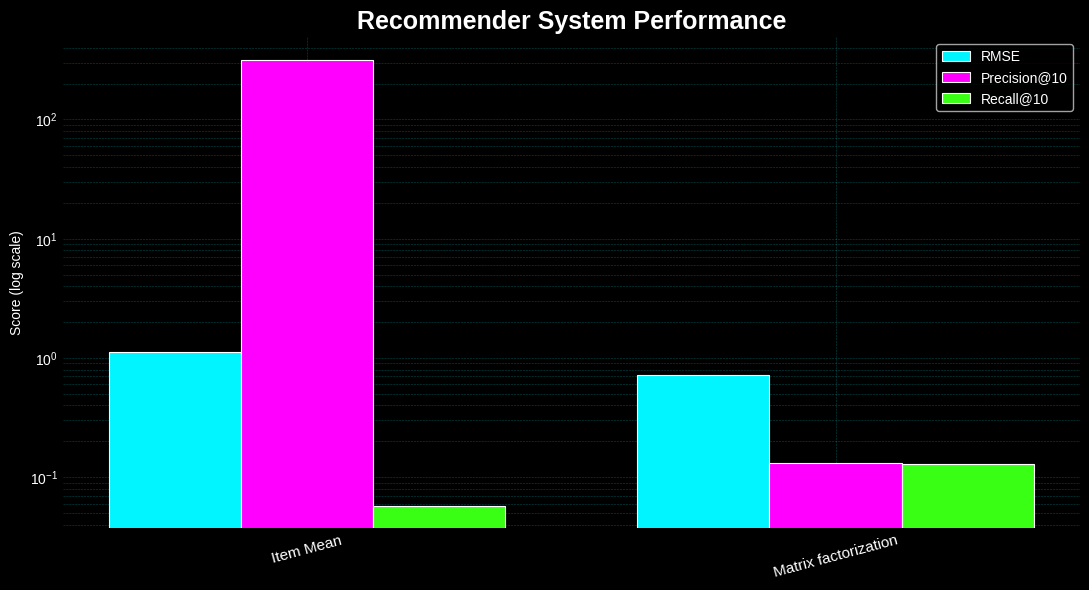

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = results_table["Model"]
x = np.arange(len(models))
width = 0.25


plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width, results_table["RMSE"], width,
       color="#00f5ff", edgecolor="white", linewidth=0.8, label="RMSE")

ax.bar(x, results_table["Precision@10"], width,
       color="#ff00ff", edgecolor="white", linewidth=0.8, label="Precision@10")

ax.bar(x + width, results_table["Recall@10"], width,
       color="#39ff14", edgecolor="white", linewidth=0.8, label="Recall@10")

ax.set_yscale("log")

ax.set_title("Recommender System Performance", fontsize=18, fontweight="bold", color="white")
ax.set_ylabel("Score (log scale)", color="white")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, fontsize=11, color="white")

ax.tick_params(axis='y', colors='white')

ax.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.3, color="cyan")

legend = ax.legend(frameon=True)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

### Issue - Data Sparsity


In [ ]:
print(f"Users DataFrame size: {users_df.shape}")
print(f"Movies DataFrame size: {movies_df.shape}")
print(f"Ratings DataFrame size: {ratings_df.shape}")

Users DataFrame size: (943, 5)
Movies DataFrame size: (1682, 24)
Ratings DataFrame size: (100000, 7)


We have 943 users, and 1682 movies. If all users were to rate all movies, we'd have over 1.5 million ratings. Yet, we only have 100,000. This means most of these user-item pairs have no interactions. With such a majority of these ratings missing, most users have only rated a very small subset of movies. This sparsity makes it difficult for the model to accurately learn user preferences and item characteristics. As a result, performances can struggle, particularly for less active users and less popular items.


#### Issue - Popularity Bias


In [ ]:

movie_rating_counts = ratings_df.groupby('item_id').size().reset_index(name='rating_count')

# Merge with movies_df to get movie titles
movie_rating_counts = pd.merge(movie_rating_counts, movies_df[['movie_id', 'movie_title']], left_on='item_id', right_on='movie_id', how='left')

# Sort by rating count to find most popular and least popular
sorted_movies_by_popularity = movie_rating_counts.sort_values(by='rating_count', ascending=False)

print("\nTop 5 Most Rated Movies:")
display(sorted_movies_by_popularity.head(5)[['movie_title', 'rating_count']])

print("\nBottom 5 Least Rated Movies:")
display(sorted_movies_by_popularity.tail(5)[['movie_title', 'rating_count']])



Top 5 Most Rated Movies:


,movie_title,rating_count
49,Star Wars (1977),583
257,Contact (1997),509
99,Fargo (1996),508
180,Return of the Jedi (1983),507
293,Liar Liar (1997),485



Bottom 5 Least Rated Movies:


,movie_title,rating_count
1618,All Things Fair (1996),1
1639,"Eighth Day, The (1996)",1
1632,Á köldum klaka (Cold Fever) (1994),1
1640,Dadetown (1995),1
1681,Scream of Stone (Schrei aus Stein) (1991),1


Another issue in our recommender systems is popularity bias, where models tend to favor items with a large number of interactions. This effect is clearly visible in the MovieLens dataset. A small number of movies such as Star Wars (1977) (583 ratings), Contact (1997) (509 ratings), and Fargo (1996) (508 ratings) dominate the dataset, while many others, such as All Things Fair (1996) and Cold Fever (1994), have only a single rating. Because popular items provide significantly more data, models produce more reliable estimates for them. As a result, these popular movies are disproportionately favored in predictions and recommendations, while less-rated items are often ignored. This leads to reduced diversity and limits the system's ability to surface niche content that may better match individual user preferences.